In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import re
from pathlib import Path

# Convergência em K-Points

In [2]:
conv_k_path : str = r'ZnO_system_preparation/dft_setup/k-convergence/dados.dat'
dados = np.loadtxt(fname=conv_k_path, delimiter=" ")
kgrid_values, total_energy, _ = dados[:,0], dados[:,1], dados[:,2]

In [3]:
kgrid_values

array([ 2.,  4.,  6.,  8., 10., 12., 14., 16., 20., 30., 40.])

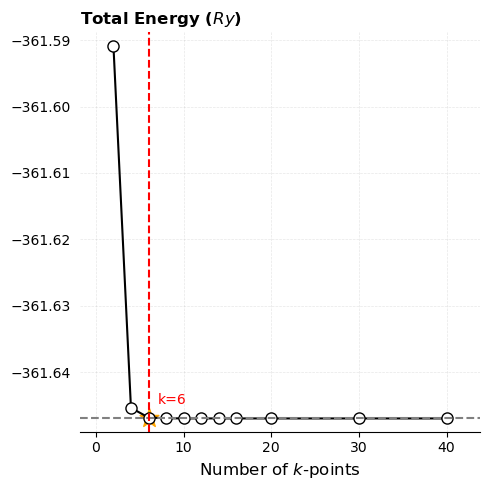

In [4]:
fig, ax = plt.subplots(figsize=(5,5))

# Points 
plt.scatter(x=kgrid_values[2], y=total_energy[2], marker='*', s=200, color='orange', label="$k = 6$") 
ax.plot(kgrid_values, total_energy, 'o-',
        color="k",
        markersize=8, markerfacecolor='white')

# Max Convergence
plt.axhline(total_energy[-1], color='gray', linestyle='--', label=f'$k$ = {kgrid_values[-1]}')

plt.axvline(x=kgrid_values[2], color='r', linestyle='--')
plt.text(
        x=kgrid_values[2] + 1,
        y=total_energy[2] + 2e-3,
        s="k=6",
        color='red'
)

# Labels
ax.set_title(r"Total Energy ($Ry$)", loc='left', weight='bold')
plt.xlabel('Number of $k$-points',fontsize=12)
plt.ylim(min(total_energy) - 0.002, max(total_energy) + 0.002)

# Remove ticks
plt.tick_params(axis='y', which='both', left=False)

# Remove bordas
ax = plt.gca() 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.3)
plt.tight_layout()

# Opção A: PNG com alta resolução (ótimo para apresentações e relatórios digitais)
plt.margins(x=0.1, y=0.1)
plt.savefig('kgrid_convergence.png', dpi=300, bbox_inches='tight')
plt.show()

# Convergência em Energy Cut-Off.

In [5]:
dados_path = r'ZnO_system_preparation/dft_setup/ecut_convergence/dados_ecut.dat'
data = pd.read_csv(dados_path, sep=' ', skipinitialspace=True, names=['Total Energy', 'ecutwfc', 'Band Gap'])
data

,Total Energy,ecutwfc,Band Gap
0,-361.248742,30,0.6873
1,-361.637191,50,0.7346
2,-361.646954,70,0.7396
3,-361.648410,90,0.7406
4,-361.648724,110,0.7408
5,-361.648966,130,0.7409
6,-361.649014,150,0.7409


In [6]:
data['Total Energy']

0   -361.248742
1   -361.637191
2   -361.646954
3   -361.648410
4   -361.648724
5   -361.648966
6   -361.649014
Name: Total Energy, dtype: float64

In [7]:
data.ecutwfc[6]

150

In [8]:
data['Total Energy'][6]

-361.64901414

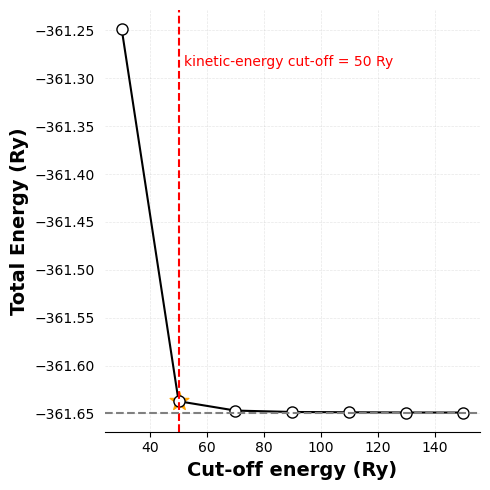

In [9]:
fig, ax = plt.subplots(figsize=(5,5))

# ax.set_title("Energy Cut-Off ($Ry$)", loc='center', weight='bold')
plt.scatter(x=data.ecutwfc[1], y=data['Total Energy'][1], marker='*', s=200, color='orange', label="$k = 6$") 
ax.plot(
    data['ecutwfc'],data['Total Energy'] , 'o-',
        color="k",
        markersize=8, markerfacecolor='white'
)
# Cut-Off Escolhido
plt.axvline(x=50, color='r', linestyle='--')
plt.text(
        x= data['ecutwfc'][1]+ 2,
        y=data['Total Energy'][1] + 0.35,
        s="kinetic-energy cut-off = 50 Ry",
        color='red'
)
# Maior Cut-Off : Max-Convergence
plt.axhline(data['Total Energy'][6], color='gray', linestyle='--', 
        label=f'$cut-off$ = {data.ecutwfc[6]}'
)

# Labels
ax.set_xlabel("Cut-off energy (Ry)", size=14, fontweight='bold')
ax.set_ylabel("Total Energy (Ry)", size=14, fontweight='bold')



# Remove ticks
plt.tick_params(axis='y', which='both', left=False)

# Remove bordas
ax = plt.gca() 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.3)
plt.savefig('ecut_convergence.png', dpi=300, bbox_inches='tight')
fig.tight_layout()

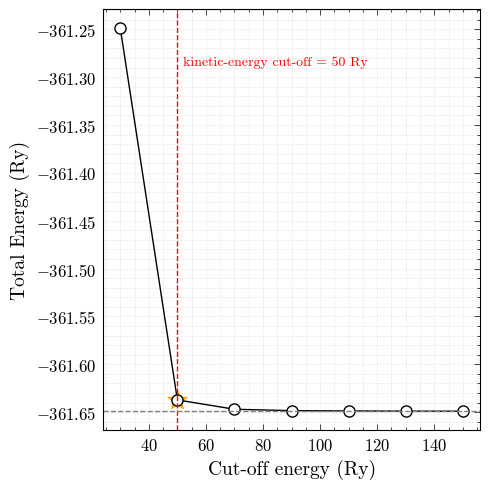

In [14]:
scientific_theme_path: str = r"/home/jvc/QEspresso7.2/ZnO_database/computermodern.mplstyle"
with plt.style.context(scientific_theme_path):
        fig, ax = plt.subplots(figsize=(5,5))

        # ax.set_title("Energy Cut-Off ($Ry$)", loc='center', weight='bold')
        plt.scatter(x=data.ecutwfc[1], y=data['Total Energy'][1], marker='*', s=200, color='orange', label="$k = 6$") 
        ax.plot(
        data['ecutwfc'],data['Total Energy'] , 'o-',
                color="k",
                markersize=8, markerfacecolor='white'
        )
        # Cut-Off Escolhido
        plt.axvline(x=50, color='r', linestyle='--')
        plt.text(
                x= data['ecutwfc'][1]+ 2,
                y=data['Total Energy'][1] + 0.35,
                s="kinetic-energy cut-off = 50 Ry",
                color='red'
        )
        # Maior Cut-Off : Max-Convergence
        plt.axhline(data['Total Energy'][6], color='gray', linestyle='--', 
                label=f'$cut-off$ = {data.ecutwfc[6]}'
        )

        # Labels
        ax.set_xlabel("Cut-off energy (Ry)", size=14, fontweight='bold')
        ax.set_ylabel("Total Energy (Ry)", size=14, fontweight='bold')



        # Remove ticks
        plt.tick_params(axis='y', which='both', left=False)

        # Remove bordas
        # ax = plt.gca() 
        # ax.spines['top'].set_visible(False)
        # ax.spines['right'].set_visible(False)
        # ax.spines['left'].set_visible(False)
        ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.3)
        plt.savefig('energy_cutoff.png', dpi=300, bbox_inches='tight')
        fig.tight_layout()
        plt.show()

---

<h1 style="
    background-color: #251351; 
    color: white; 
    padding: 10px; 
    text-align: left; 
    font-family: Arial, sans-serif; 
    font-size: 32px; 
    font-weight: bold; 
    margin: 10px 0;">
    Figuras de Resultados
</h1>



In [10]:
def get_supercell_data(data_dir: str) -> pd.DataFrame:
    """ Monta um DataFrame com informações para um tamanho fixo de supercélula (diretório).
    
    data_dir: Diretório contendo arquivos ZnO-*.out.
    """
    dados = []
    
    pattern_bloco = r"Forces acting on atoms \(cartesian axes, Ry/au\):\n(.*?)\n\s*The non-local contrib\.  to forces"
    pattern_linha_bloco: Match = r"atom\s+(\d+)\s+type\s+(\d+)\s+force\s*=\s*([-\d.eE]+)\s+([-\d.eE]+)\s+([-\d.eE]+)"

    scf_outputs: list[Path] = [file for file in data_dir.iterdir() if file.is_file() and file.suffix == '.out']
    
    for scf in scf_outputs:
        sim_id: str = scf.name.replace(".out", "")
        # sim_id: str = scf.stem
        with open(scf) as arquivo:
            conteudo_arquivo = arquivo.read()

            # Análise regex Força
            match_do_bloco: Match = re.search(pattern_bloco, conteudo_arquivo, re.DOTALL)

            # Primeio grupo de forcas 
            bloco_da_forca = match_do_bloco.group(0)
            bloco_da_forca = bloco_da_forca.split('\n')[2:-1]  # Remove as linhas de cabeçalho e rodapé
            bloco_da_forca = [linha.strip() for linha in bloco_da_forca if linha.strip()]  # Remove linhas vazias


            #numero_atomo, tipo_atomo, fx, fy, fz, modulo_forca = extrai_dados_bloco(bloco_da_forca)

            # Análise regex no Bloco
            for linhas in bloco_da_forca:
                match_linha = re.match(pattern_linha_bloco, linhas)
                if match_linha:
                    numero_atomo = int(match_linha.group(1))
                    tipo_atomo = int(match_linha.group(2))
                    
                    fx, fy, fz = match_linha.group(3), match_linha.group(4), match_linha.group(5)
                    modulo_forca = np.linalg.norm([fx, fy, fz])        

                    dados.append({
                            "sim_id": sim_id,
                            "atom_id": numero_atomo,
                            "atom_type": tipo_atomo,
                            "fx_Ry_bohr": fx,
                            "fy_Ry_bohr": fy,
                            "fz_Ry_bohr": fz,
                            "modulo_Ry_bohr": modulo_forca,
                            "modulo_eV_A": modulo_forca * 25.711,
                        })
    dataframe = pd.DataFrame(dados)
    dataframe['label_atom'] = dataframe['atom_type'].map({1: 'Zn', 2: 'O'})
    return dataframe
